<h1 align="center">GPR Hyperparameters</h1>

## **Pip Installs**

pip install matplotlib (3.10.7)

pip install numpy (2.3.5)

pip install pandas(2.3.3)

pip install seaborn(0.13.2)

pip install tqdm(4.67.1)

pip install scikit_learn(1.7.2)



In [117]:
# Install the requirements
%pip install matplotlib numpy pandas seaborn tqdm scikit_learn

Note: you may need to restart the kernel to use updated packages.


## Purpose Of Notebook

The Gaussian Process Regressor (GPR) algorithm heavily relies on initial hyperparameter values to begin its optimization process. If these initial guesses are poor, the model can fail to converge or get stuck in a bad local minimum, leading to an incorrect fit. To use GPR in an automated pipeline for various signals, we cannot manually tune these parameters each time. Therefore, we must programmatically approximate, or "guess," these hyperparameters based on the incoming signal's properties.

This is achieved using statistical heuristics, such as analyzing the signal after masking out the spectral lines. By isolating the baseline, we can intelligently estimate parameters like noise_level from the high-frequency variations and length_scale from the baseline's overall smoothness. This automated estimation provides a robust starting point and bounds, ensuring the GPR can reliably model the background.

In [110]:
import time
from enum import Enum

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RationalQuadratic
from tqdm import tqdm


## Create Background Function

In [ ]:
class SignalType(Enum):
    POLYONIMAL = 1
    SIN = 2
    BOTH = 3

def background_creation(freq : np.ndarray , signal_type : SignalType ,noise_level : str ) -> tuple:
    """
    Create a signal according to the signal type we want and add noise according to the noise level.

    Args:
        freq (np.ndarray): Frequencies Array
        signal_type (SignalType): The type of the signal(sin,poly,both)
        noise_level (str): How strong will the noise be

    Returns:
        tuple: return the clear noise that was calculated for comparisons in noise approach and the signal.
    """
    # create a Generator Instance
    rng = np.random.default_rng()

    # --- Creation of Noise ---
    noise = np.zeros(freq.shape)
    if noise_level == "High":
        noise = rng.normal(0 , 0.7 , freq.shape)
    elif noise_level == "Medium":
        noise = rng.normal(0 , 0.5 , freq.shape)
    elif noise_level == "Low":
        noise = rng.normal(0 , 0.2 , freq.shape)

    #  --- Creation of Baseline ---
    # is_polyonimal = True -> signal = a(frequencies - 1420)^2 + b
    # is_sin = True -> signal = A* sin (ω  * (frequencies - 1418) + phase)
    # is_both = True -> signal = polyonimal + sin
    signal = np.zeros(freq.shape)

    # Add the sin component if the signal is sin or has both sin and polyonimal compoonents
    if signal_type in (SignalType.SIN, SignalType.BOTH) :
        amplitude = rng.uniform(0.5 , 1)
        omega = 2 * np.pi * rng.uniform(low = 0.2 , high = 0.8)
        phase = rng.uniform(low = 0 , high = 2*np.pi)
        signal += amplitude * np.sin(omega*(freq-1418) + phase)

    #Add the poly component if the signal is poly or has both poly and sin components
    if signal_type in (SignalType.POLYONIMAL , SignalType.BOTH):
        a = rng.uniform(low=-0.5 , high = 1)
        b = rng.uniform(low=3 , high = 7)
        signal+= a * (freq-1420)**2 + b

    return noise , signal + noise


## Noise_level & Noise_bounds Approach

We will create 1000 different signals.200 of them will have low noise , 300 of them will have medium noise and 500 will have high noise.We will check if the noise approach was succesfull or not

### The Noise Estimation Method:

The method we are using, 'np.median(np.abs(np.diff(y_signal))) ' , is a robust statistical heuristic designed to estimate the standard deviation ($\sigma$) of the high-frequency "white noise" in a signal, even when that noise is superimposed on a changing baseline.

### The Error Estimation Pipeline

Here is a concise summary of my analysis pipeline:

To evaluate the performance of the noise estimation method, I analyzed the data from 1,000 simulations.

First, I calculated the overall average percentage error across all runs to get a single, top-level performance metric.

Next, to understand the method's specific strengths and weaknesses, I grouped the results by the two experimental variables: the signal_type (e.g., Polynomial, Sinusoidal) and the noise_level (Low, Medium, High). I then calculated the mean percentage error for each specific combination (e.g., the average error for all "Polynomial" + "Low Noise" runs).

Finally, I organized this 2D matrix of errors and plotted it as a heatmap. This visualization makes it easy to immediately identify which types of background signals or noise levels cause the estimation method to perform poorly (high error) versus where it succeeds (low error).

Execute 1000 simulations...


100%|██████████| 1000/1000 [00:00<00:00, 5207.24it/s]


Simulation Complete!

--- Total performance of  noise estimation---
 Average Percentage Error: 4.91%

--- Mean Percantage Error per Category --- 
noise_level       Low    Medium      High
signal_type                              
Poly+Sine    5.302701  4.500783  4.961423
Polynomial   5.065762  4.910272  4.708453
Sinusoidal   4.483130  4.865797  5.310698


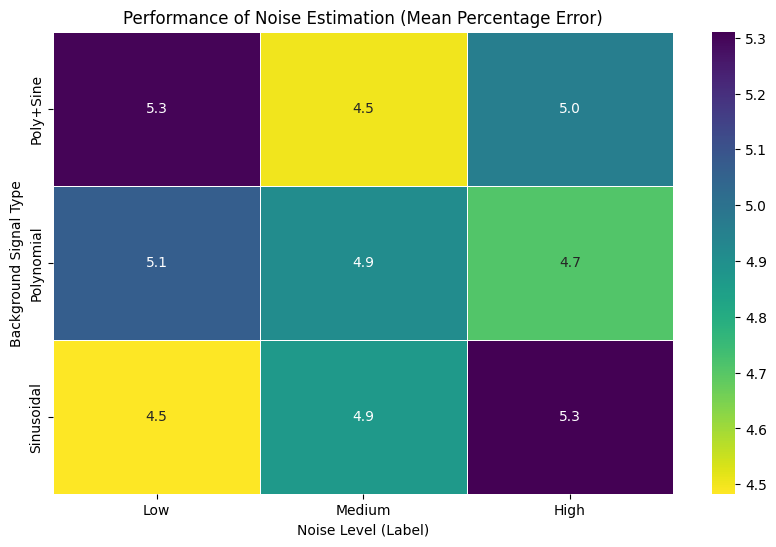

In [112]:
# create a Generator Instance
rng = np.random.default_rng()


frequencies = np.linspace(1418,1422,1024)
runs = 1000



#create the "schedule" for the noise level
noise_levels = ["Low"]*200 + ["Medium"]*300 + ["High"]*500
rng.shuffle(noise_levels)

results = [] # list to save the results

# --- Simulation Procces Implementation ---
print(f"Execute {runs} simulations...")
for i in tqdm(range(runs)):
    noise_level_label = noise_levels[i]

    # Random selection of the background
    possible_signals = [SignalType.POLYONIMAL,SignalType.SIN,SignalType.BOTH]
    signal_type = rng.choice(possible_signals)

    true_noise , y_observed = background_creation(frequencies,signal_type,noise_level_label)

    true_noise_std = np.std(true_noise)

    # --- Noise std Approach ---
    noise_guess = np.median(np.abs(np.diff(y_observed)))

    error = np.abs(noise_guess-true_noise_std)
    if true_noise_std>0:
        error_percent = (error/true_noise_std)*100

    # Label for the heatmap
    if signal_type == SignalType.BOTH:
        signal_type_label = "Poly+Sine"
    elif signal_type == SignalType.POLYONIMAL:
        signal_type_label = "Polynomial"
    elif signal_type == SignalType.SIN:
        signal_type_label = "Sinusoidal"

    results.append({
        "noise_level": noise_level_label,
        "signal_type": signal_type_label,
        "error_percent": error_percent,
        "true_std": true_noise_std,
        "guessed_std": noise_guess,
    })

print("Simulation Complete!")
results_df = pd.DataFrame(results)

# Total Performance
print("\n--- Total performance of  noise estimation---")
print(f" Average Percentage Error: {results_df['error_percent'].mean():.2f}%")


# Creation of the heatmap
heatmap_data = results_df.pivot_table(
    values="error_percent",
    index="signal_type",
    columns="noise_level",
    aggfunc="mean" ,   # What function i want (mean)
)
heatmap_data = heatmap_data[["Low" , "Medium" , "High"]]

print("\n--- Mean Percantage Error per Category --- ")
print(heatmap_data)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="viridis_r", linewidths=.5)
plt.title("Performance of Noise Estimation (Mean Percentage Error)")
plt.xlabel("Noise Level (Label)")
plt.ylabel("Background Signal Type")
plt.show()


## Length Scale Approach

### What length scale is:

The length scale is a hyperparameter that determines the smoothness of the function by defining the distance over which data points are strongly correlated. A larger length scale forces the model to fit a smooth, global trend, while a smaller value allows it to capture rapid, local fluctuations.

### How can we estimate length scale?

To objectively initialize the RBF kernel, we employ the Autocorrelation Method on the unmasked background data.In particular We utilize the largest continuous segment of unmasked data found either to the left or right of the spectral line, because Autocorrelation requires a continuous data series without gaps to function correctly. By selecting the longest available background segment, we ensure the most statistically robust estimation of the continuum's trends, while completely excluding the spectral feature to prevent parameter contamination.

We calculate the autocorrelation function (ACF) of the signal and define the characteristic length scale as the lag distance where the correlation coefficient decays to $1/e$ ($\approx 0.37$). This data-driven approach ensures the GPR effectively models the smooth background trend while avoiding overfitting to high-frequency noise.

### The Error Estimation pipeline

Here is a concise summary of my analysis pipeline:

To evaluate the performance of the length scale estimation method we will create 1000 different signals and try to estimate the real length scale.However in contrast to the noise we dont know the length scale of a signal.GPR is being used for regression and fitting but it is a generative model.That means that GPR can create data which obey some rules.As a result we will use the Gaussian process to create signals in which the length scale will be known because we defined it.

To make the signals realisitc we will use the Ration Quadratic kernel and we will create signals with many curves.

Therefore we will create 1000 signals using GPR and we will try to estimate the length scale with auto correlation

#### Function that generates the signals

In [ ]:
def generate_signals(freq : np.ndarray , length_sc : float , signals_number : int) -> tuple :
    """
    Create the Gaussian process and creates a number of masked signals(simulate the spectral line area) with the length_scale we defined.

    Args:
        freq (np.ndarray): the frequencies axes
        length_sc (float): the true length scale we want the signals to have
        signals_number (int): the number of signals with this particual length scale we want to create

    Returns:
        tuple: the signals and the masks.
    """
    rng = np.random.default_rng()



    kernel = 1.0 * RationalQuadratic(length_scale=length_sc,alpha = 5) # alpha means that the signal will not be a line but a multi curved signal
    gp = GaussianProcessRegressor(kernel=kernel)

    y_samples = gp.sample_y(freq.reshape(-1,1) , n_samples=signals_number)

    # y_samples shape : (freq.length , signals_number)

    # create noise to add in the signals
    noise = rng.normal(0,0.05,size=y_samples.shape)
    y_noisy = y_samples + noise

    # Initialize the mask
    mask = np.zeros(y_noisy.shape , dtype=bool)

    # The mask will be around 1419 and 1421 for 0.8 Mhz so the max start will be 1420.2
    max_start = 1420.2

    # We select signals_number random start points
    starts = rng.uniform(1419,max_start,signals_number)

    # We apply the mask to the signals
    for i in range(signals_number):
        start = starts[i]
        end = start + 0.8
        mask[:,i] = (freq > start) & (freq < end)


    return y_noisy , mask

#### Function that finds the biggest part of the signal without the mask

In [114]:
def get_largest_valid_segment(signal : np.ndarray , mask : np.ndarray) -> np.ndarray :
    """
    Find the biggest part of the data where the data are not interupted by the mask.

    Args:
        signal (np.ndarray): the original signal without the mask
        mask (np.ndarray): the mask that will be applied

    Returns:
        np.ndarray: The signal array that will be the data for the autocrrelation
    """
    # Invert the boolean values in the mask and take the potential areas
    valid_indices = np.where(~mask)[0]
    # Find the indices where a cuntinuous data segment end's because it is interuppted by the mask
    breaks = np.where(np.diff(valid_indices) > 1)[0]

    # Find the areas that arenn't interrupted by the mask and takes the biggest
    segments = []
    start = 0
    for b in breaks:
        end = b+1
        segments.append(signal[valid_indices[start:end]])
        start = end
    segments.append(signal[valid_indices[start:]])

    return max(segments,key=len)



#### The Length scale estimation method(Autocorrelation)

In [115]:
def estimate_length_scale(signal : np.ndarray , mask : np.ndarray, dx : float) -> float :
    """
    Estimate the length scale using the auto correlation method.

    Args:
        signal (np.ndarray): the signal from which we want to estimate the length scale
        mask (np.ndarray) : the mask of the signal where the spectral line is
        dx (float): Sampling Step

    Returns:
        float: the estimation of the length scale
    """
    # Find the biggest segment of data
    y_segment = get_largest_valid_segment(signal , mask)

    # center the signal so the autocorrelation is around 0
    y_centered = y_segment - np.mean(y_segment)
    corr = np.correlate(y_centered,y_centered,mode="full")

    # The result of the mode = full  is symetric.The point in the middle (size//2) is the Lag 0.We are intersted in the distance as we move forward(Lag >=0).
    corr = corr[corr.size//2:]

    # Normalize the data of the correlation with the lag 0 (corr[0]) because at lag 0 the signal completely identifies with itself and the value is the variance of the signal.
    # We want a coefficient from 0 to 1 therefore doing corr/=corr[0] we force the curve to start from 1
    corr /=corr[0]

    # we save the indexes that has correlation < 0.368
    one_e = 0.368
    below = np.where(corr<one_e)[0]

    if len(below)>0 :
        # We will define the interpolation boundaries

        idx2 = below[0] # The first point under the 0.368
        idx1 = idx2 - 1 # The last point over 0.368

        if idx1 < 0:
            #If the correlation was under 0.368 at the first step then the signal is almost just noise so we return the minimum possible length
            return dx

        # Calculate the sub-pixel accuracy
        # The curve is a line between two points and we find where 0.368 is located in this line
        fraction = (corr[idx1]- 0.368/corr[idx1] - corr[idx2])

        #isx1 + fraction is the position of the length_scale in pixels
        return (idx1+fraction)*dx

    # if the correlation was never below 0.368
    return np.nan


#### Run the simulation

Running Simulation...
The Simulation Duration was : 9.70 sec.
Mean Absolute Error : 42.46%


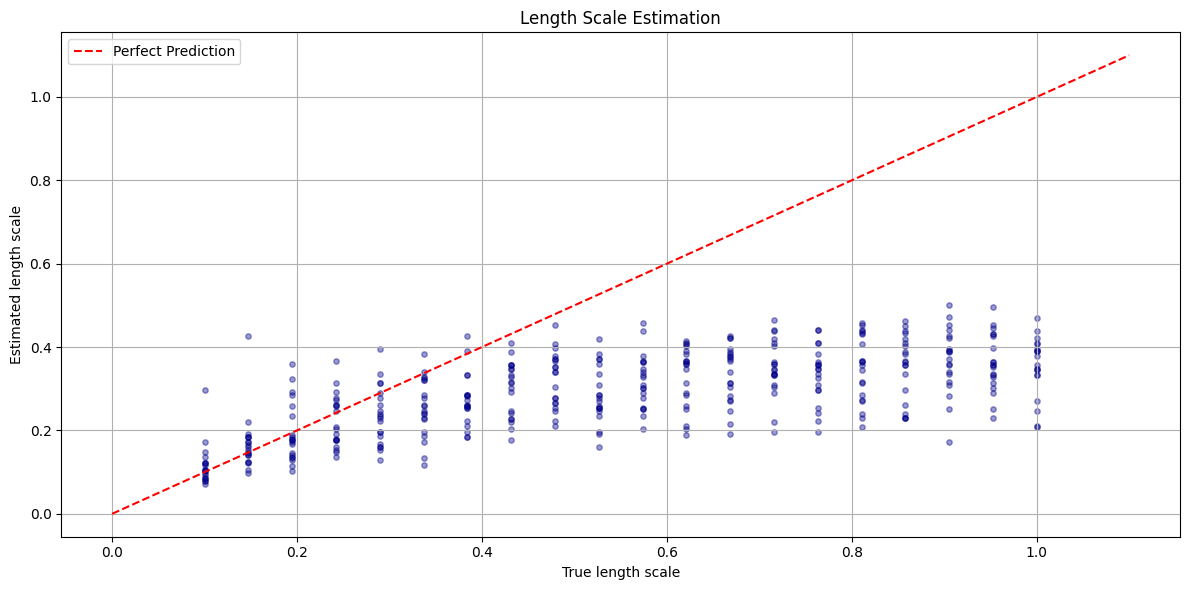

In [116]:
frequencies = np.linspace(1418,1422,1024)
dx = frequencies[1]-frequencies[0]
length_values = np.linspace(0.1,1,20)
results = []

print("Running Simulation...")
start_time = time.time()

for true_len in length_values:
    # We call the function that creates the signal
    signals , masks = generate_signals(freq=frequencies,length_sc=true_len,signals_number=20)

    for i in range(20):
        # for the i iteration we save the signal and it's mask
        y = signals[:,i]
        mask = masks[:,i]

        # We estimate the length_scale
        length_estimated = estimate_length_scale(y,mask,dx)

        if not np.isnan(length_estimated):
            error = (length_estimated-true_len)/true_len * 100
            results.append({"True" : true_len , "Estimated" : length_estimated , "Error" : error})
duration = time.time()-start_time

df = pd.DataFrame(results)
print(f"The Simulation Duration was : {duration :.2f} sec.")
print(f"Mean Absolute Error : {df['Error'].abs().mean() :.2f}%")

plt.figure(figsize=(12, 6))
plt.scatter(df["True"] , df["Estimated"] , alpha=0.4 , c="darkblue" , s=15)
plt.plot([0, 1.1], [0, 1.1], "r--", label="Perfect Prediction")
plt.xlabel("True length scale")
plt.ylabel("Estimated length scale")
plt.title("Length Scale Estimation")
plt.legend()
plt.grid(visible=True)
plt.tight_layout()
plt.show()


#### Comments

We can see that we have a mean absolute error 41% which is not good.However the purpose of the autocorrelation is to provide a logical , data-driven initial guess for the GPR and not to find the true length scale.It needs more complex methods to estimate the length scale than an autocorreletion, so the MAPE is acceptable.In Addition , the error is that big because of the simulation that we tried to do a realistic procdeure but the 1/e limit is not accurate for the Rational Quadratic kernel.However we needed the Quadratic kernel to make complex signals.

Conclusion: The high error reflects the difficulty of the simulation itself. The GPR's inherent optimization capabilities will compensate for this initial offset, rendering the $41\%$ error a temporary and necessary artifact of the strategic initialization process.

## Signal Variance Approach

The coefficient signal variance **A** is the amplitude/variance of teh background signal.The simpliest and statistical right way to estimate teh signal variance is using the Variance Decomposition.

Variance Decomposition : The total variance in the data is the sum of the noise variance and the signal variance. We have estimated the noise variance before so the only thing we have to do is to substract the noise variance from the total variance fo the siganl and we will have the signal variance.

So if we have the signal with the background and the noise and we have estimated the noise std and masked the spectral line what we have to do is:

$$\text{Variance}_{\text{Signal}} = \text{Variance}_{\text{Total}} - \text{Variance}_{\text{Noise}}$$

$$\text{Variance}_{\text{Noise}} = \text{STD}_{\text{Noise}}^2 $$

$$\text{Variance}_{\text{Total}} = np.var(signal) $$